## **Сетевые программы**

Хотя многие примеры в этой книге были сосредоточены на чтении файлов и поиске данных в них, при работе с Интернетом существует множество различных источников информации.

В этой главе мы будем имитировать работу веб-браузера и получать веб-страницы с помощью протокола передачи гипертекста (HTTP). Затем мы будем читать данные веб-страницы и разбирать их.


### **Протокол передачи гипертекста — HTTP**

Сетевой протокол, на котором работает веб, на самом деле довольно прост. В Python существует встроенная поддержка работы с сетью — модуль <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">socket</span>, который позволяет легко устанавливать сетевые соединения и получать данные через сокеты в программе на Python.

Сокет во многом похож на файл, за исключением того, что один сокет обеспечивает двустороннее соединение между двумя программами. Через один и тот же сокет можно как читать, так и записывать данные. Если отправить данные в сокет, они будут переданы приложению на другом конце соединения. Если читать из сокета, возвращаются данные, отправленные другой программой.

Однако если попытаться прочитать из сокета, когда программа на другом конце ещё не отправила данные, выполнение будет ожидать. Если программы на обоих концах сокета будут только ждать данные, не отправляя ничего, ожидание может длиться очень долго. Поэтому важной частью программ, взаимодействующих через Интернет, является использование протокола.

Протокол — это набор точных правил, определяющих, кто начинает взаимодействие, что именно делает каждая сторона, какие ответы должны следовать, кто отправляет данные следующим и так далее. В некотором смысле два приложения на концах сокета «танцуют», стараясь не мешать друг другу.

Существует множество документов, описывающих сетевые протоколы. Протокол передачи гипертекста описан в следующем документе:

[https://www.w3.org/Protocols/rfc2616/rfc2616.txt](https://www.w3.org/Protocols/rfc2616/rfc2616.txt)

Это большой и сложный документ объёмом 176 страниц, содержащий множество деталей. При желании можно изучить его полностью. Однако если открыть примерно страницу 36 документа RFC2616, можно найти синтаксис запроса GET. Чтобы запросить документ у веб-сервера, необходимо установить соединение, например с сервером <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">[www.pr4e.org](http://www.pr4e.org)</span> на порту 80, а затем отправить строку следующего вида:

<span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">GET [http://data.pr4e.org/romeo.txt](http://data.pr4e.org/romeo.txt) HTTP/1.0</span>

где второй параметр — это запрашиваемая веб-страница. После этого также отправляется пустая строка. Веб-сервер отвечает заголовками, содержащими информацию о документе, затем пустой строкой и после неё — содержимым документа.


### **Самый простой веб-браузер в мире**

Пожалуй, самый простой способ показать, как работает протокол HTTP, — написать очень простую программу на Python, которая устанавливает соединение с веб-сервером и, следуя правилам протокола HTTP, запрашивает документ и выводит ответ сервера.


In [ ]:
import socket

mysock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
mysock.connect(("data.pr4e.org", 80))
cmd = "GET http://data.pr4e.org/romeo.txt HTTP/1.0\r\n\r\n".encode()
mysock.send(cmd)

while True:
    data = mysock.recv(512)
    if len(data) < 1:
        break
    print(data.decode(), end="")

mysock.close()

HTTP/1.1 200 OK
Date: Thu, 26 Mar 2026 09:14:42 GMT
Server: Apache/2.4.52 (Ubuntu)
Last-Modified: Sat, 13 May 2017 11:22:22 GMT
ETag: "a7-54f6609245537"
Accept-Ranges: bytes
Content-Length: 167
Cache-Control: max-age=0, no-cache, no-store, must-revalidate
Pragma: no-cache
Expires: Wed, 11 Jan 1984 05:00:00 GMT
Connection: close
Content-Type: text/plain

But soft what light through yonder window breaks
It is the east and Juliet is the sun
Arise fair sun and kill the envious moon
Who is already sick and pale with grief


Сначала программа устанавливает соединение с портом 80 на сервере <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">[www.pr4e.com](http://www.pr4e.com)</span>. Поскольку наша программа выполняет роль «веб-браузера», протокол HTTP требует отправить команду GET, за которой следует пустая строка. Последовательность <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">\r\n</span> обозначает конец строки (EOL), поэтому <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">\r\n\r\n</span> означает отсутствие данных между двумя последовательностями конца строки. Это эквивалент пустой строки.


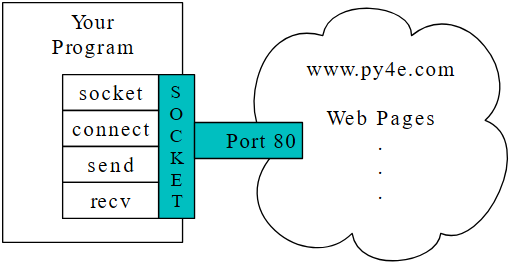

Сокетное соединение

После отправки пустой строки запускается цикл, который получает данные из сокета блоками по 512 символов с помощью метода <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span> и выводит их до тех пор, пока данные не закончатся (то есть пока <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span> не вернёт пустую строку).

Вывод начинается с заголовков, которые веб-сервер отправляет для описания документа. Например, заголовок <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">Content-Type</span> указывает, что документ является текстовым (<span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">text/plain</span>).

После отправки заголовков сервер добавляет пустую строку, чтобы обозначить их завершение, а затем передаёт фактическое содержимое файла _romeo.txt_.

Этот пример демонстрирует, как установить низкоуровневое сетевое соединение с помощью сокетов. Сокеты можно использовать для взаимодействия с веб-сервером, почтовым сервером и многими другими типами серверов. Всё, что требуется, — это найти документ, описывающий соответствующий протокол, и написать код для отправки и получения данных в соответствии с этим протоколом.

Однако, поскольку наиболее часто используется веб-протокол HTTP, в Python существует специальная библиотека, предназначенная для поддержки этого протокола при получении документов и данных из сети.

Одним из требований при работе с протоколом HTTP является необходимость отправлять и получать данные в виде объектов байтов, а не строк. В предыдущем примере методы <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">encode()</span> и <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">decode()</span> выполняют преобразование строк в байтовые объекты и обратно.

В следующем примере используется запись <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">b''</span>, указывающая, что переменная должна храниться как объект байтов. Использование <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">encode()</span> и <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">b''</span> эквивалентно.


In [ ]:
b"Hello world"

b'Hello world'

In [ ]:
"Hello world".encode()

b'Hello world'

### **Получение изображения по HTTP**

В приведённом выше примере был получен текстовый файл, содержащий символы перевода строки, и данные просто выводились на экран по мере выполнения программы. Аналогичную программу можно использовать для получения изображения по протоколу HTTP. Вместо вывода данных на экран по мере выполнения программы данные накапливаются в строке, затем удаляются заголовки, после чего данные изображения сохраняются в файл следующим образом:


In [ ]:
import socket
import time

HOST = "data.pr4e.org"
PORT = 80
mysock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
mysock.connect((HOST, PORT))
mysock.sendall(b"GET http://data.pr4e.org/cover3.jpg HTTP/1.0\r\n\r\n")
count = 0
picture = b""

while True:
    data = mysock.recv(5120)
    if len(data) < 1:
        break
    # time.sleep(0.25)
    count = count + len(data)
    print(len(data), count)
    picture = picture + data

mysock.close()

# Ищем конец заголовка
pos = picture.find(b"\r\n\r\n")
print("Header length", pos)
print(picture[:pos].decode())

# Пропустим заголовок и сохраним данные изображения
picture = picture[pos + 4 :]
fhand = open("stuff.jpg", "wb")
fhand.write(picture)
fhand.close()

1163 1163
5006 6169
543 6712
3990 10702
2378 13080
4096 17176
2852 20028
5120 25148
3182 28330
446 28776
5120 33896
2728 36624
2616 39240
5120 44360
112 44472
2616 47088
2616 49704
2616 52320
5120 57440
112 57552
2616 60168
2616 62784
5120 67904
112 68016
2616 70632
2616 73248
2616 75864
5120 80984
112 81096
2616 83712
2616 86328
2616 88944
2616 91560
2616 94176
5120 99296
2728 102024
2616 104640
2616 107256
5120 112376
2728 115104
2616 117720
2616 120336
2616 122952
2616 125568
2616 128184
2616 130800
5120 135920
5120 141040
5120 146160
5120 151280
5120 156400
5120 161520
5120 166640
5120 171760
5120 176880
5120 182000
5120 187120
5120 192240
5120 197360
4138 201498
5120 206618
5120 211738
5120 216858
5120 221978
5120 227098
3510 230608
Header length 394
HTTP/1.1 200 OK
Date: Thu, 26 Mar 2026 09:16:57 GMT
Server: Apache/2.4.52 (Ubuntu)
Last-Modified: Mon, 15 May 2017 12:27:40 GMT
ETag: "38342-54f8f2e5b6277"
Accept-Ranges: bytes
Content-Length: 230210
Vary: Accept-Encoding
Cache-Contro

Можно увидеть, что для данного URL заголовок <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">Content-Type</span> указывает, что содержимое документа является изображением (<span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">image/jpeg</span>). После завершения программы можно просмотреть изображение, открыв файл *stuff.jpg* в программе для просмотра изображений.

По мере выполнения программы можно заметить, что при каждом вызове метода <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span> возвращается не ровно 5120 символов. Мы получаем столько данных, сколько на данный момент было передано веб-сервером по сети к моменту вызова <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span>. В данном примере при запросе до 5120 символов за один раз может возвращаться, например, около 3200 символов.

Результаты могут отличаться в зависимости от скорости сети. Также обратите внимание, что при последнем вызове <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span> возвращается 3167 байт, что означает конец потока, а при следующем вызове <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span> возвращается строка нулевой длины, что указывает на то, что сервер вызвал метод <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">close()</span> на своей стороне сокета и данные больше не будут поступать.

Можно замедлить последовательные вызовы <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span>, раскомментировав вызов <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">time.sleep()</span>. В этом случае после каждого вызова выполняется пауза примерно в четверть секунды, чтобы сервер успел «опередить» клиента и отправить больше данных до следующего вызова <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span>.

### (пропущен вывод)

Теперь, за исключением первого и последнего вызовов <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span>, при каждом запросе новых данных возвращается по 5120 символов.

Между сервером, выполняющим вызовы <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">send()</span>, и приложением, выполняющим вызовы <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">recv()</span>, существует буфер. Когда программа выполняется с задержкой, в какой-то момент сервер может заполнить буфер сокета и будет вынужден приостановиться до тех пор, пока программа не начнёт его освобождать. Такая приостановка отправляющего или принимающего приложения называется «управлением потоком» (flow control).


### **Получение веб-страниц с помощью urllib**

Хотя можно вручную отправлять и получать данные по протоколу HTTP с использованием библиотеки <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">socket</span>, в Python существует гораздо более простой способ выполнения этой задачи — с помощью библиотеки <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span>.

При использовании <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span> веб-страница обрабатывается практически так же, как файл. Достаточно указать адрес страницы, которую требуется получить, а <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span> самостоятельно обрабатывает все детали протокола HTTP и заголовков.

Эквивалентный код для чтения файла *romeo.txt* из сети с использованием <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span> выглядит следующим образом:


In [ ]:
import urllib.request

fhand = urllib.request.urlopen("http://data.pr4e.org/romeo.txt")
for line in fhand:
    print(line.decode().strip())

But soft what light through yonder window breaks
It is the east and Juliet is the sun
Arise fair sun and kill the envious moon
Who is already sick and pale with grief


После открытия веб-страницы с помощью <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib.request.urlopen</span> её можно обрабатывать как файл и читать с использованием цикла <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">for</span>.

При выполнении программы выводится только содержимое файла. Заголовки также передаются, но код <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span> обрабатывает их и возвращает пользователю только данные.

В качестве примера можно написать программу, которая получает данные файла *romeo.txt* и вычисляет частоту появления каждого слова в этом файле следующим образом:


In [ ]:
import urllib.request, urllib.parse, urllib.error

fhand = urllib.request.urlopen("http://data.pr4e.org/romeo.txt")

counts = dict()
for line in fhand:
    words = line.decode().split()
    for word in words:
        counts[word] = counts.get(word, 0) + 1
print(counts)

{'But': 1, 'soft': 1, 'what': 1, 'light': 1, 'through': 1, 'yonder': 1, 'window': 1, 'breaks': 1, 'It': 1, 'is': 3, 'the': 3, 'east': 1, 'and': 3, 'Juliet': 1, 'sun': 2, 'Arise': 1, 'fair': 1, 'kill': 1, 'envious': 1, 'moon': 1, 'Who': 1, 'already': 1, 'sick': 1, 'pale': 1, 'with': 1, 'grief': 1}


Снова отметим, что после открытия веб-страницы её можно читать так же, как локальный файл.


### **Чтение бинарных файлов с использованием urllib**

Иногда требуется получить не текстовый (бинарный) файл, например изображение или видео. Данные в таких файлах, как правило, не имеют смысла при выводе на экран, однако с помощью <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span> можно легко сохранить содержимое по URL в локальный файл.

Типичный подход заключается в том, чтобы открыть URL и с помощью метода <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">read</span> загрузить всё содержимое документа в переменную (например, <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">img</span>), а затем записать эти данные в локальный файл следующим образом:


In [ ]:
import urllib.request, urllib.parse, urllib.error

img = urllib.request.urlopen("http://data.pr4e.org/cover3.jpg").read()
fhand = open("cover3.jpg", "wb")
fhand.write(img)
fhand.close()

Эта программа считывает все данные из сети за один раз и сохраняет их в переменной <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">img</span> в оперативной памяти компьютера, затем открывает файл *cover.jpg* и записывает данные на диск. Аргумент <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">wb</span> в функции <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">open()</span> открывает файл в бинарном режиме только для записи. Эта программа будет работать, если размер файла меньше объёма оперативной памяти компьютера.

Однако если файл большой (например, аудио или видео), программа может завершиться с ошибкой или работать очень медленно из-за нехватки памяти. Чтобы избежать этого, данные считываются блоками (буферами), и каждый блок записывается на диск перед получением следующего. Такой подход позволяет обрабатывать файлы любого размера, не занимая всю доступную оперативную память.


In [ ]:
import urllib.request, urllib.parse, urllib.error

img = urllib.request.urlopen("http://data.pr4e.org/cover3.jpg")
fhand = open("cover3.jpg", "wb")
size = 0
while True:
    info = img.read(100000)
    if len(info) < 1:
        break
    size = size + len(info)
    fhand.write(info)

print(size, "characters copied.")
fhand.close()

230210 characters copied.


В этом примере за один раз считывается только 100 000 символов, после чего эти данные записываются в файл *cover3.jpg* перед получением следующих 100 000 символов из сети.


### **Разбор HTML и веб-скрейпинг**

Одним из распространённых способов использования возможностей <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span> в Python является веб-скрейпинг. Веб-скрейпинг — это процесс, при котором программа имитирует работу веб-браузера, загружает страницы, а затем анализирует их содержимое в поиске определённых шаблонов.

Например, поисковая система, такая как <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">Google</span>, анализирует исходный код одной веб-страницы, извлекает ссылки на другие страницы, загружает их, затем снова извлекает ссылки и так далее. Используя этот подход, <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">Google</span> «переходит» по практически всем страницам в интернете.

Также <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">Google</span> учитывает количество ссылок с других страниц на конкретную страницу как один из показателей её «важности» и использует это при определении позиции страницы в результатах поиска.


### **Разбор HTML с использованием регулярных выражений**

Один из простых способов разбора HTML — использовать регулярные выражения для многократного поиска и извлечения подстрок, соответствующих заданному шаблону.

Вот пример простой веб-страницы:


Можно составить корректное регулярное выражение, которое будет находить и извлекать значения ссылок из приведённого выше текста, следующим образом:


In [ ]:
'''
<h1>The First Page</h1>
<p>
If you like, you can switch to the
<a href="http://www.dr-chuck.com/page2.htm">
Second Page</a>.
</p>
'''

Можно составить корректное регулярное выражение, которое будет находить и извлекать значения ссылок из приведённого выше текста, следующим образом:


In [ ]:
href = "http[s]?://.+?"

Наше регулярное выражение ищет строки, которые начинаются с «href="http://» или «href="https://», за которыми следует один или более символов (<span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">.+?</span>), а затем — ещё одна двойная кавычка. Знак вопроса после конструкции <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">[s]?</span> означает, что выполняется поиск строки «http» с последующим наличием нуля или одного символа «s».

Знак вопроса, добавленный к <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">.+?</span>, указывает, что сопоставление должно выполняться в «нежадном» режиме (non-greedy), а не в «жадном» (greedy). Нежадное сопоставление пытается найти минимально возможную подходящую строку, тогда как жадное — максимально возможную.

Мы добавляем круглые скобки в регулярное выражение, чтобы указать, какую часть найденной строки необходимо извлечь, и получаем следующую программу:


In [ ]:
import urllib.request, urllib.parse, urllib.error
import re
import ssl

# Игнорируем ошибки SSL сертификата
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

url = input("Enter - ")
html = urllib.request.urlopen(url, context=ctx).read()
links = re.findall(b'href="(http[s]?://.*?)"', html)
for link in links:
    print(link.decode())

https://docs.python.org/3/index.html
https://www.python.org/
https://docs.python.org/3.15/
https://docs.python.org/3.14/
https://docs.python.org/3.13/
https://docs.python.org/3.12/
https://docs.python.org/3.11/
https://docs.python.org/3.10/
https://docs.python.org/3.9/
https://docs.python.org/3.8/
https://docs.python.org/3.7/
https://docs.python.org/3.6/
https://docs.python.org/3.5/
https://docs.python.org/3.4/
https://docs.python.org/3.3/
https://docs.python.org/3.2/
https://docs.python.org/3.1/
https://docs.python.org/3.0/
https://docs.python.org/2.7/
https://docs.python.org/2.6/
https://www.python.org/doc/versions/
https://peps.python.org/
https://wiki.python.org/moin/BeginnersGuide
https://wiki.python.org/moin/PythonBooks
https://www.python.org/doc/av/
https://devguide.python.org/
https://www.python.org/
https://devguide.python.org/documentation/help-documenting/
https://docs.python.org/3.15/
https://docs.python.org/3.14/
https://docs.python.org/3.13/
https://docs.python.org/3.12/


Библиотека <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">ssl</span> позволяет программе получать доступ к веб-сайтам, которые строго требуют использования HTTPS. Метод <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">read</span> возвращает исходный HTML-код в виде объекта байтов, а не объекта HTTPResponse. Метод регулярных выражений <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">findall</span> возвращает список всех строк, соответствующих заданному регулярному выражению, извлекая только текст ссылок, заключённый в двойные кавычки.

Регулярные выражения хорошо работают тогда, когда HTML-код правильно оформлен и предсказуем по структуре. Однако, поскольку существует много «сломанных» HTML-страниц, решение, основанное только на регулярных выражениях, может либо пропустить некоторые корректные ссылки, либо извлечь неверные данные.

Эту проблему можно решить с помощью надёжной библиотеки для разбора HTML.


### **Разбор HTML с использованием BeautifulSoup**

Хотя HTML внешне похож на XML, и некоторые страницы действительно создаются как XML, большинство HTML-страниц содержит ошибки, из-за которых XML-парсер отклоняет их как некорректно сформированные.

Существует множество библиотек Python, которые помогают разбирать HTML и извлекать данные со страниц. У каждой из них есть свои преимущества и недостатки, поэтому выбор зависит от конкретных задач.

В качестве примера рассмотрим разбор HTML и извлечение ссылок с использованием библиотеки <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">BeautifulSoup</span>. Эта библиотека корректно обрабатывает даже сильно повреждённый HTML и позволяет удобно извлекать необходимые данные. Скачать и установить <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">BeautifulSoup</span> можно по ссылке:

[https://pypi.python.org/pypi/beautifulsoup4](https://pypi.python.org/pypi/beautifulsoup4)

Информация об установке <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">BeautifulSoup</span> с использованием инструмента <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">pip</span> доступна здесь:

[https://packaging.python.org/tutorials/installing-packages/](https://packaging.python.org/tutorials/installing-packages/)

В примере используется <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">urllib</span> для чтения страницы, после чего с помощью <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">BeautifulSoup</span> извлекаются значения атрибутов <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">href</span> из тегов <span style="color: #c70000; background-color: #da7ec325; padding:2px 6px; border-radius:4px;">a</span>.


In [ ]:
from urllib.request import urlopen
from bs4 import BeautifulSoup
import ssl

# Игнорируем ошибки SSL сертификата
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

url = input("Enter - ")
html = urlopen(url, context=ctx).read()
soup = BeautifulSoup(html, "html.parser")

# Извлекаем все теги привязки
tags = soup("a")
for tag in tags:
    # Смотрим на части тегов
    print("TAG:", tag)
    print("URL:", tag.get("href", None))
    print("Contents:", tag.contents[0])
    print("Attrs:", tag.attrs)

TAG: <a href="http://www.dr-chuck.com/page2.htm">
Second Page</a>
URL: http://www.dr-chuck.com/page2.htm
Contents: 
Second Page
Attrs: {'href': 'http://www.dr-chuck.com/page2.htm'}


In [ ]:
curl -O http://www.py4e.com/cover.jpg

In [ ]:
wget http://www.py4e.com/cover.jpg

# Exercise 1: Change the socket program socket1.py to prompt the user for the URL so it can read any web page.
You can use split('/') to break the URL into its component parts so you can extract the host name for the socket connect call. Add error checking using try and except to handle the condition where the user enters an improperly formatted or non-existent URL.

In [1]:
import socket

url = input("Enter - ")

try:
    host = url.split("/")[2]

    my_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    my_socket.connect((host, 80))

    cmd = f"GET {url} HTTP/1.0\r\n\r\n".encode()
    my_socket.send(cmd)

    while True:
        data = my_socket.recv(512)
        if len(data) < 1:
            break
        print(data.decode(), end="")

    my_socket.close()

except IndexError:
    print("Ошибка: Некорректный формат URL. Ожидается формат 'http://host/path'.")
except socket.gaierror:
    print(f"Ошибка: Не удалось подключиться к хосту '{host}'. Проверьте адрес.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

HTTP/1.1 200 OK
Date: Sat, 28 Mar 2026 08:06:06 GMT
Server: Apache/2.4.52 (Ubuntu)
Last-Modified: Sat, 13 May 2017 11:22:22 GMT
ETag: "a7-54f6609245537"
Accept-Ranges: bytes
Content-Length: 167
Cache-Control: max-age=0, no-cache, no-store, must-revalidate
Pragma: no-cache
Expires: Wed, 11 Jan 1984 05:00:00 GMT
Connection: close
Content-Type: text/plain

But soft what light through yonder window breaks
It is the east and Juliet is the sun
Arise fair sun and kill the envious moon
Who is already sick and pale with grief


# Exercise 2: Change your socket program so that it counts the number of characters it has received and stops displaying any text after it has shown 3000 characters. The program should retrieve the entire document and count the total number of characters and display the count of the number of characters at the end of the document.

In [3]:
import socket

url = input("Enter - ")

try:
    host = url.split("/")[2]

    my_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    my_socket.connect((host, 80))

    cmd = f"GET {url} HTTP/1.0\r\n\r\n".encode()
    my_socket.send(cmd)

    total_chars = 0
    displayed_chars = 0
    limit = 3000

    while True:
        data = my_socket.recv(512)
        if len(data) < 1:
            break

        text = data.decode()
        total_chars += len(text)

        if displayed_chars < limit:
            chars_to_print = min(limit - displayed_chars, len(text))
            print(text[:chars_to_print], end="")
            displayed_chars += chars_to_print

    my_socket.close()

    print("\n\n" + "=" * 40)
    print(f"Отображено символов: {displayed_chars}")
    print(f"Всего символов получено: {total_chars}")

except IndexError:
    print("Ошибка: Некорректный формат URL. Ожидается формат 'http://host/path'.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

HTTP/1.1 200 OK
Date: Sat, 28 Mar 2026 08:06:43 GMT
Server: Apache/2.4.52 (Ubuntu)
Last-Modified: Sat, 13 May 2017 11:22:22 GMT
ETag: "a7-54f6609245537"
Accept-Ranges: bytes
Content-Length: 167
Cache-Control: max-age=0, no-cache, no-store, must-revalidate
Pragma: no-cache
Expires: Wed, 11 Jan 1984 05:00:00 GMT
Connection: close
Content-Type: text/plain

But soft what light through yonder window breaks
It is the east and Juliet is the sun
Arise fair sun and kill the envious moon
Who is already sick and pale with grief


Отображено символов: 536
Всего символов получено: 536


# Exercise 3: Use urllib to replicate the previous exercise of (1) retrieving the document from a URL, (2) displaying up to 3000 characters, and (3) counting the overall number of characters in the document. Don’t worry about the headers for this exercise, simply show the first 3000 characters of the document contents.

In [4]:
import urllib.request
import urllib.error

url = input("Enter - ")

try:
    fhand = urllib.request.urlopen(url)

    total_chars = 0
    displayed_chars = 0
    limit = 3000

    for line in fhand:
        text = line.decode()
        total_chars += len(text)

        if displayed_chars < limit:
            chars_to_print = min(limit - displayed_chars, len(text))
            print(text[:chars_to_print], end="")
            displayed_chars += chars_to_print

    print("\n\n" + "=" * 40)
    print(f"Отображено символов: {displayed_chars}")
    print(f"Всего символов получено: {total_chars}")

except Exception as e:
    print(f"Произошла ошибка: {e}")

But soft what light through yonder window breaks
It is the east and Juliet is the sun
Arise fair sun and kill the envious moon
Who is already sick and pale with grief


Отображено символов: 167
Всего символов получено: 167


# Exercise 4: Change the urllinks.py program to extract and count paragraph (p) tags from the retrieved HTML document and display the count of the paragraphs as the output of your program. Do not display the paragraph text, only count them. Test your program on several small web pages as well as some larger web pages.

In [9]:
import urllib.request
from bs4 import BeautifulSoup
import ssl

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

url = input("Enter - ")

try:
    html = urllib.request.urlopen(url, context=ctx).read()
    soup = BeautifulSoup(html, "html.parser")
    tags = soup("p")
    count = len(tags)

    print(f"Количество тегов <p> на странице: {count}")

except Exception as e:
    print(f"Произошла ошибка: {e}")

Количество тегов <p> на странице: 29


# Exercise 5: (Advanced) Change the socket program so that it only shows data after the headers and a blank line have been received. Remember that recv receives characters (newlines and all), not lines.

In [10]:
import socket

url = input("Enter - ")

try:
    host = url.split("/")[2]

    my_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    my_socket.connect((host, 80))

    cmd = f"GET {url} HTTP/1.0\r\n\r\n".encode()
    my_socket.send(cmd)

    document = b""

    while True:
        data = my_socket.recv(512)
        if len(data) < 1:
            break
        document += data

    my_socket.close()

    pos = document.find(b"\r\n\r\n")

    if pos != -1:
        body = document[pos + 4 :]
        print(body.decode().strip())
    else:
        print(document.decode().strip())

except Exception as e:
    print(f"Произошла ошибка: {e}")

But soft what light through yonder window breaks
It is the east and Juliet is the sun
Arise fair sun and kill the envious moon
Who is already sick and pale with grief
